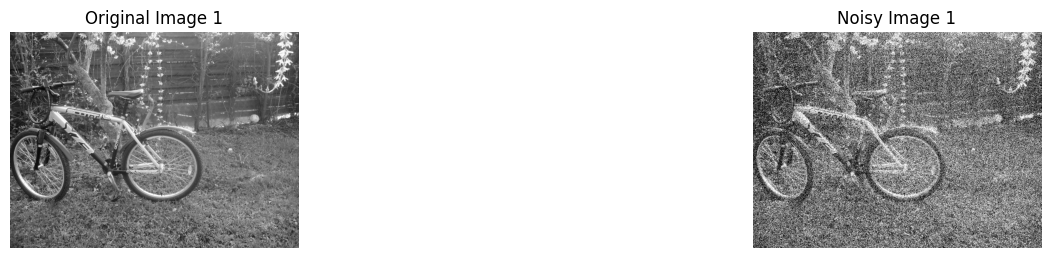


Results for Image 1:


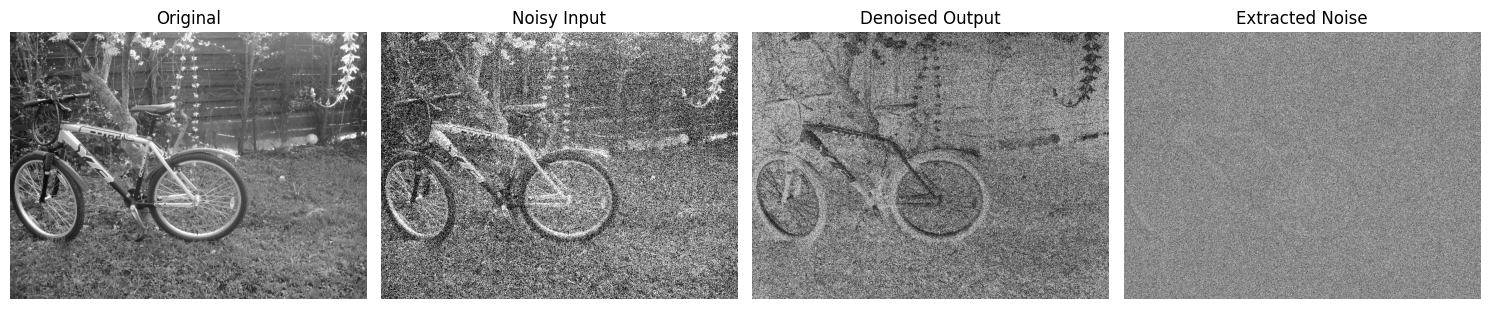


Histograms:


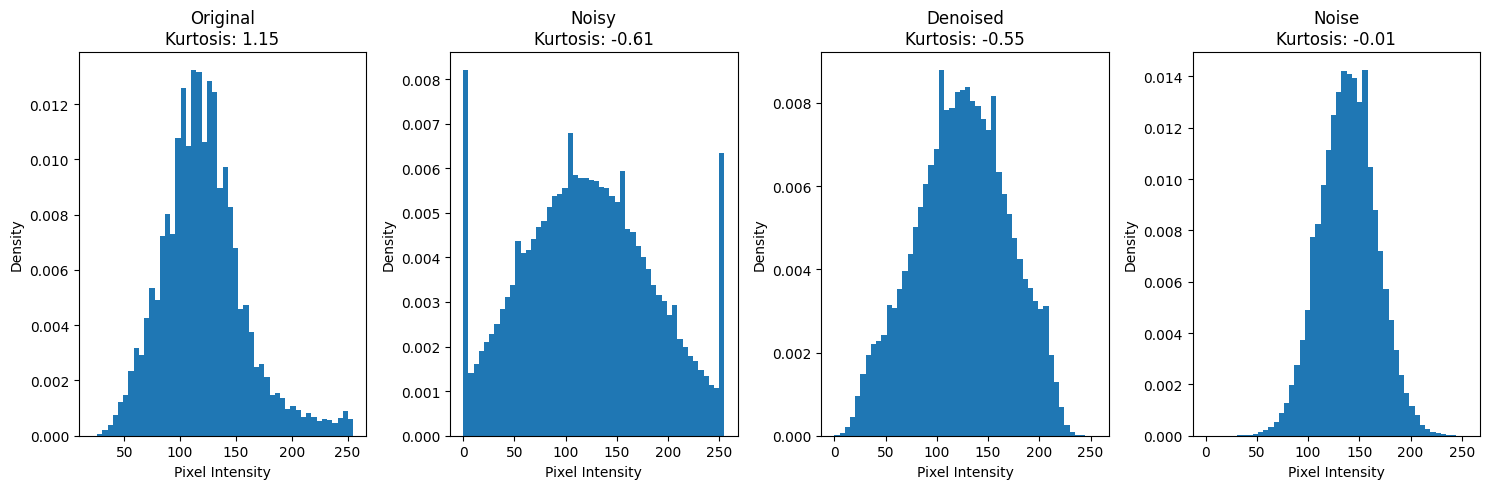

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
from skimage.util import random_noise

def load_images(image_paths):
    images = []
    for path in image_paths:
        img = Image.open(path).convert('L')
        images.append(np.array(img))

    if len({img.shape for img in images}) > 1:
        raise ValueError("All images must have the same dimensions")

    return images

def add_noise_to_images(images, noise_type='gaussian', var=0.005):
    noisy_images = []
    for img in images:
        img_float = img.astype(float)/255
        noisy_img = random_noise(img_float, mode=noise_type, var=var)
        noisy_images.append((noisy_img*255).astype('uint8'))
    return noisy_images

def center_data(X):
    return X - np.mean(X, axis=1, keepdims=True)

def whiten_data(X):
    cov = np.cov(X)
    d, E = np.linalg.eigh(cov)
    D = np.diag(1. / np.sqrt(d + 1e-5))
    W = E @ D @ E.T
    return W @ X

def custom_fastica(X, max_iter=1000, tol=1e-4):
    n, p = X.shape
    W = np.random.randn(n, n)

    for _ in range(max_iter):
        wx = W @ X
        g = np.tanh(wx)
        g_prime = 1 - g**2

        W_new = (X @ g.T) / p - np.diag(g_prime.mean(axis=1)) @ W

        W_new, _ = np.linalg.qr(W_new)

        lim = max(abs(abs(np.diag(W_new @ W.T)) - 1))
        if lim < tol:
            break

        W = W_new

    return W

def plot_histograms(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.hist(img.flatten(), bins=50, density=True)
        plt.title(f"{title}\nKurtosis: {kurtosis(img.flatten(), fisher=True):.2f}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

def separate_noise_from_images(noisy_images):
    clean_images = []
    noise_components = []

    for i, noisy_img in enumerate(noisy_images):
        mixed1 = noisy_img + np.random.normal(0, 10, noisy_img.shape)
        mixed2 = noisy_img + np.random.normal(0, 10, noisy_img.shape)
        mixtures = np.array([mixed1, mixed2])

        X = mixtures.reshape(mixtures.shape[0], -1)
        X_centered = center_data(X)
        X_white = whiten_data(X_centered)

        W = custom_fastica(X_white)
        separated = W @ X_white

        kurtoses = [kurtosis(comp) for comp in separated]
        signal_idx = np.argmax(kurtoses)
        noise_idx = 1 - signal_idx

        clean_signal = separated[signal_idx].reshape(noisy_img.shape)
        noise_component = separated[noise_idx].reshape(noisy_img.shape)

        clean_signal = (clean_signal - clean_signal.min()) / (clean_signal.max() - clean_signal.min()) * 255
        noise_component = (noise_component - noise_component.min()) / (noise_component.max() - noise_component.min()) * 255

        clean_images.append(clean_signal.astype('uint8'))
        noise_components.append(noise_component.astype('uint8'))

    return clean_images, noise_components

if __name__ == "__main__":
    image_paths = ['/content/bike_002.jpg']
    originals = load_images(image_paths)

    noisy_images = add_noise_to_images(originals, noise_type='gaussian', var=0.05)

    plt.figure(figsize=(15, 5))
    for i, (orig, noisy) in enumerate(zip(originals, noisy_images)):
        plt.subplot(2, 2, i*2+1)
        plt.imshow(orig, cmap='gray')
        plt.title(f"Original Image {i+1}")
        plt.axis('off')

        plt.subplot(2, 2, i*2+2)
        plt.imshow(noisy, cmap='gray')
        plt.title(f"Noisy Image {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    clean_images, noise_components = separate_noise_from_images(noisy_images)

    for i, (orig, noisy, noise, clean) in enumerate(zip(originals, noisy_images, clean_images, noise_components)):
        print(f"\nResults for Image {i+1}:")

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 4, 1)
        plt.imshow(orig, cmap='gray')
        plt.title("Original")
        plt.axis('off')

        plt.subplot(1, 4, 2)
        plt.imshow(noisy, cmap='gray')
        plt.title("Noisy Input")
        plt.axis('off')

        plt.subplot(1, 4, 3)
        plt.imshow(clean, cmap='gray')
        plt.title("Denoised Output")
        plt.axis('off')

        plt.subplot(1, 4, 4)
        plt.imshow(noise, cmap='gray')
        plt.title("Extracted Noise")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        print("\nHistograms:")
        plot_histograms([orig, noisy, clean, noise],
                       ["Original", "Noisy", "Denoised", "Noise"])